# Import Library

In [67]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
import kagglehub
import optuna
import joblib
import os

# Data Overview

In [15]:
data_path = kagglehub.competition_download('titanic')
train_path = os.path.join (data_path, 'train.csv')
test_path = os.path.join (data_path, 'test.csv')

data = pd.read_csv(train_path); data.name = 'data'
submission = pd.read_csv(test_path); submission.name = 'submission'
all_df = pd.concat ([data, submission], axis = 0).reset_index(drop=True); all_df.name = 'all_df'
all_list = [data, submission, all_df]

In [16]:
all_df.sample (10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0.0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
566,567,0.0,3,"Stoytcheff, Mr. Ilia",male,19.0,0,0,349205,7.8958,NaN,S
624,625,0.0,3,"Bowen, Mr. David John ""Dai""",male,21.0,0,0,54636,16.1000,NaN,S
953,954,NaN,3,"Bjorklund, Mr. Ernst Herbert",male,18.0,0,0,347090,7.7500,NaN,S
1037,1038,NaN,1,"Hilliard, Mr. Herbert Henry",male,NaN,0,0,17463,51.8625,E46,S
311,312,1.0,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
291,292,1.0,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C
320,321,0.0,3,"Dennis, Mr. Samuel",male,22.0,0,0,A/5 21172,7.2500,NaN,S
237,238,1.0,2,"Collyer, Miss. Marjorie ""Lottie""",female,8.0,0,2,C.A. 31921,26.2500,NaN,S
487,488,0.0,1,"Kent, Mr. Edward Austin",male,58.0,0,0,11771,29.7000,B37,C


# EDA

In [17]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(3), int64(4), str(5)
memory usage: 122.8 KB


Numerical: PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare


Object (possibly Categorical): Name, Sex, Ticket, Cabin, Embarked

In [18]:
all_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


According to the table:
* Only 38.3% of Passengers survived
* Less than 25% of Passengers are 2nd Class, 1st Class
* 75% Passenger's Age <= 39 years old, 50% Age <= 28 years old; The average age of survivor is ~30 years old
* Not many people came with Companion; if they do, it's more likely that their Companion is Sibling or Spouse
* 75% Passenger paid <= 31 dollars 50% of them paid < 15 dollars; meanwhile, Survivors paid 33.3 dollars in average.

Intial Deduction:
* It is unclear if Age affects surviving chance, since the deviation from mean value is 14,4 years old
* People from 1st & 2nd, and those paid higher price had more chance of surviving -> The Rich were more likely to survive

In [19]:
def nan_report (df: pd.DataFrame):
    count = df.isna().sum()
    percent = count / df.isna().count() * 100
    nan_summary = pd.concat ([count, percent], keys = ['Count', 'Percent'], axis = 1)
    nan_summary = nan_summary[nan_summary['Percent'] > 0]
    print (nan_summary); print()
nan_report (data); nan_report(submission)

          Count    Percent
Age         177  19.865320
Cabin       687  77.104377
Embarked      2   0.224467

       Count    Percent
Age       86  20.574163
Fare       1   0.239234
Cabin    327  78.229665



Analysis:
* The number of missing values in Age, Cabin, Fare is reasonable
* ~77% of Cabin is missing in both sets -> Extract information and consider Dropping

# Fill Age, Embarked, Fare

In [20]:
for df in all_list:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [21]:
# Correlation between Age and other numerical features
corr_matrix = all_df.select_dtypes(include = [int, float]).corr().unstack().sort_values (kind = 'quicksort', ascending = False).reset_index()
corr_matrix[corr_matrix['level_0'] == 'Age']

,level_0,level_1,0
4,Age,Age,1.000000
14,Age,Fare,0.177528
24,Age,PassengerId,0.028814
38,Age,Survived,-0.077221
40,Age,Parch,-0.150917
41,Age,SibSp,-0.243699
46,Age,Pclass,-0.408106


Analysis: 
* Age has greatest negative correlation with Pclass
* Our speculation is confirmed: Age is not highly correlated with Survived

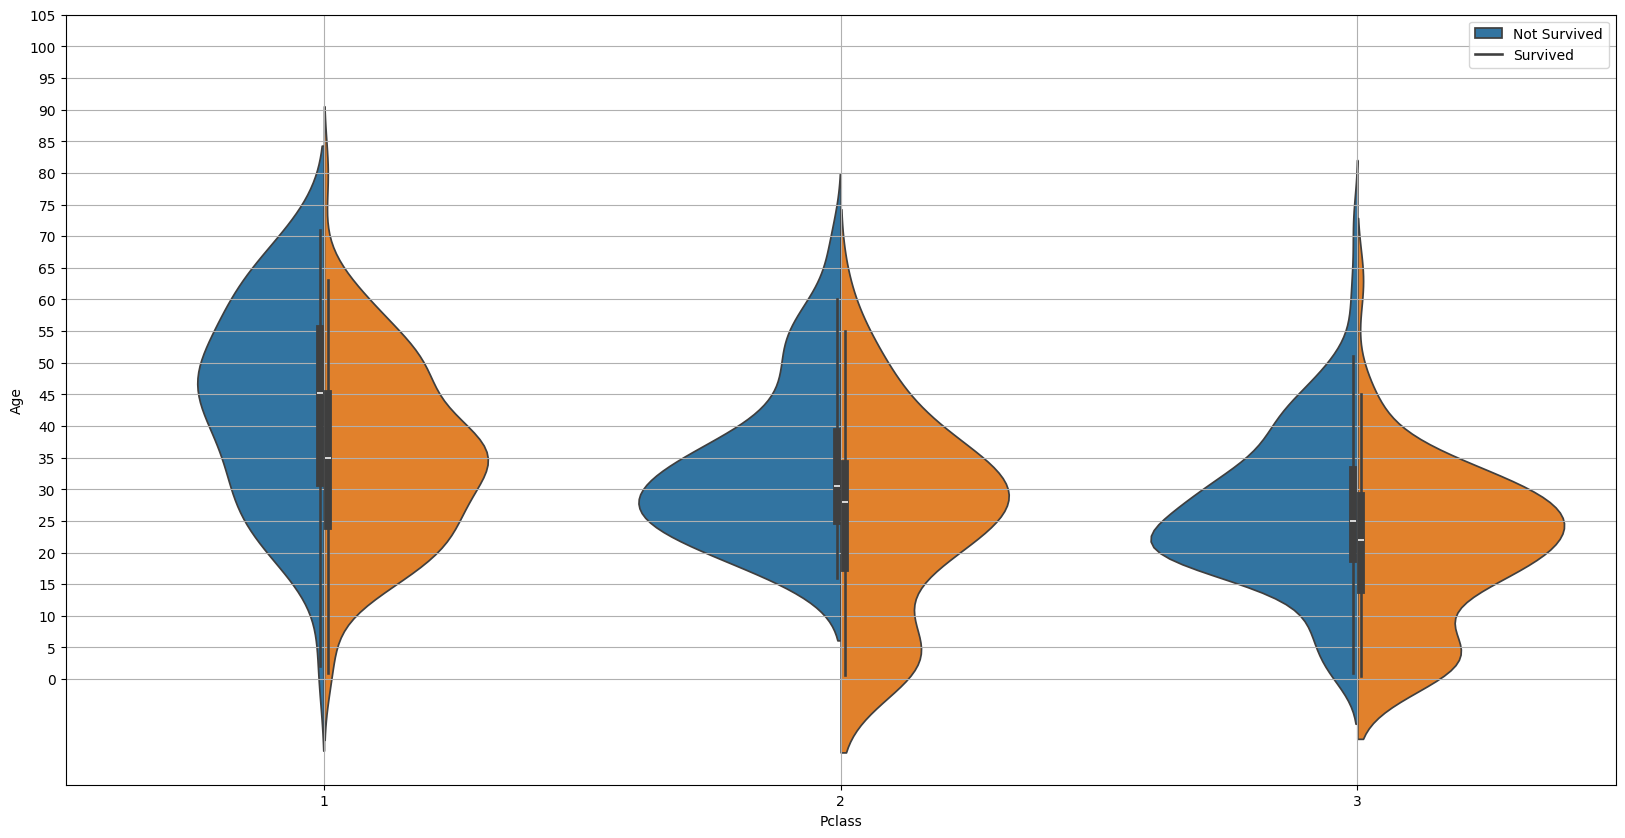

In [22]:
_, axes = plt.subplots (figsize = (20, 10))
sns.violinplot(
    data = data,
    x = 'Pclass',
    y = 'Age', 
    hue = 'Survived',
    split = True,
    ax = axes,
)
plt.legend (['Not Survived', 'Survived']),
axes.set_yticks (range(0, 110, 5))
plt.grid (True)
plt.show()

Analysis:
* Class 2 and 3 have more children (age <= 10); Chidlren in class 2 and 3 had high chance of surviving
* People from 20 - 50 years old in class 1 had highest surviving chance
* Class 1 has highest surviving rate


Conclusion:
* Pclass is an ideal feature to fill Age
* Explore categorical features is also needed to see if any feature is highly relevant to Age

In [23]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


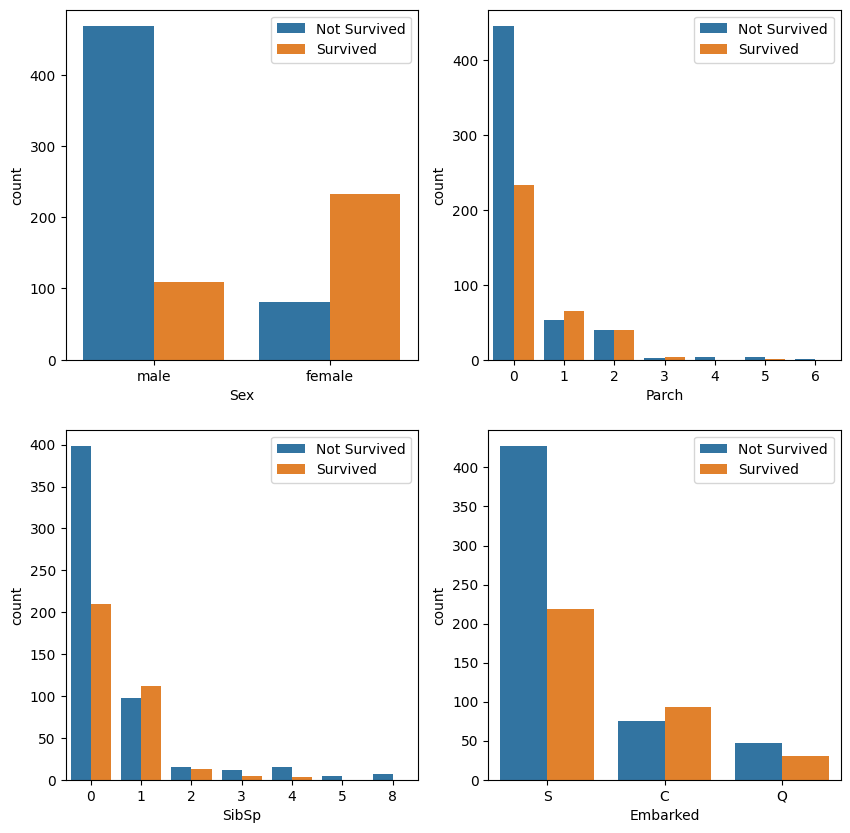

In [24]:
cat_features = ['Sex', 'Parch', 'SibSp', 'Embarked']
_, axes = plt.subplots (ncols = 2, nrows = 2, figsize = (10, 10))
for i, feature in enumerate(cat_features, 1):
    plt.subplot (2,2,i)
    sns.countplot(
        data = data,
        x = feature, 
        hue = 'Survived',
    )
    plt.legend (['Not Survived', 'Survived'])
plt.show()

Analysis
* Sex has high correlation with Surviving rate
* SibSp and Parch are right skewed, people with 1 - 3 companions has slightly higher chance of surviving
* S is the most common port, C has highest surviving chance

Conclusion:
* Sex and Embarked has low cardinality
* Age mightbe correlated with either of two features

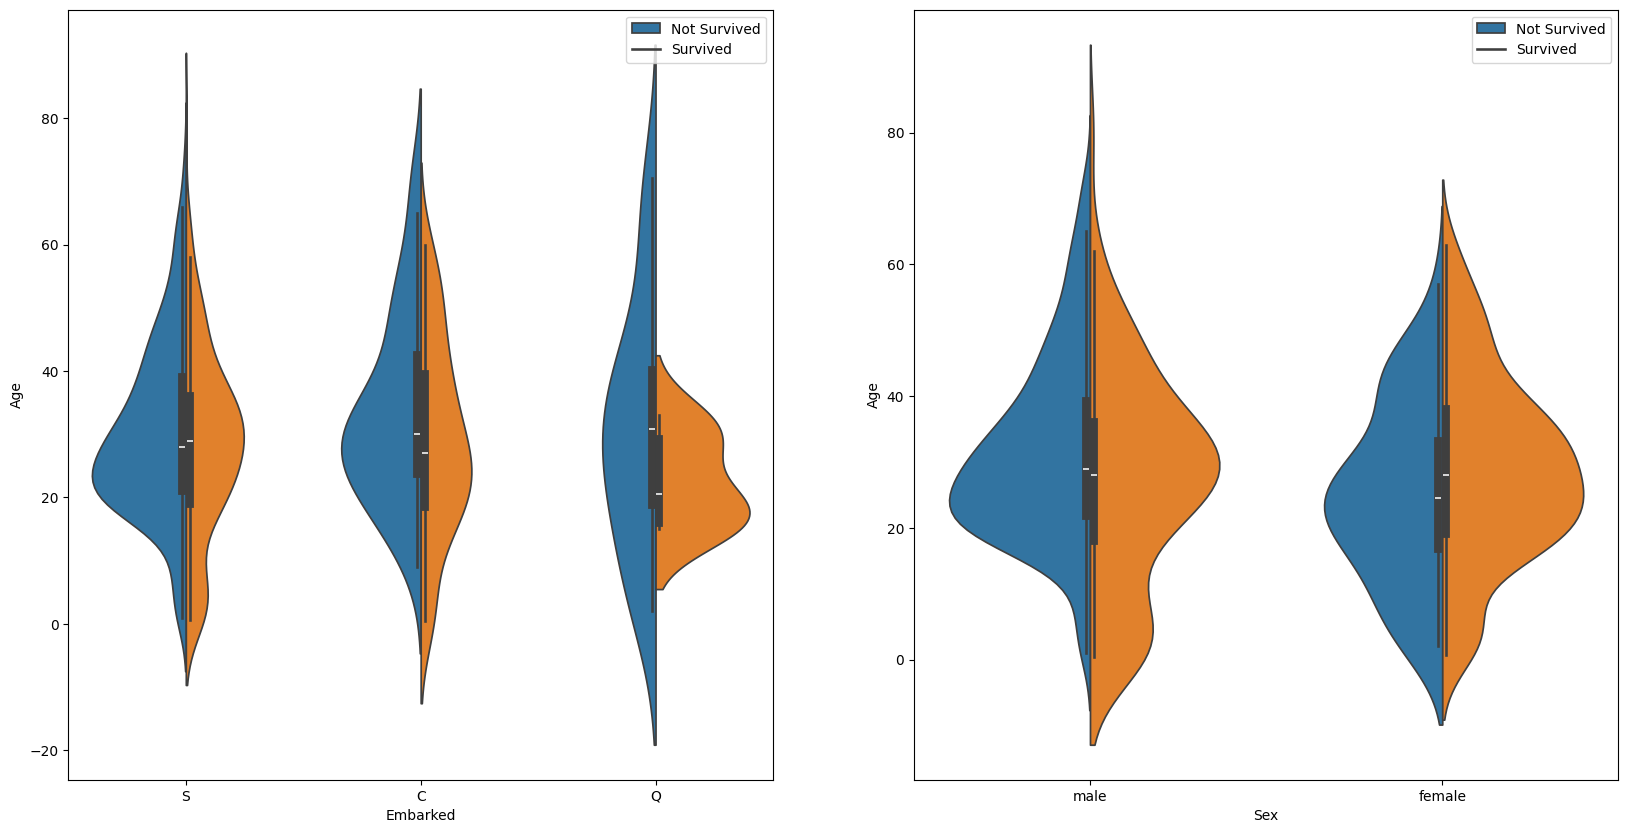

In [25]:
temp = ['Embarked', 'Sex']
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (20, 10))
for i, feature in enumerate(temp, 1):
    plt.subplot (1,2,i)
    sns.violinplot(
        data = data,
        x = feature,
        y = 'Age',
        hue = 'Survived', 
        split = True,
    )
    plt.legend (['Not Survived', 'Survived'], loc = 'upper right')
plt.show()

Analysis:
* The surviving chance according to age is more identical between two genders
* Surviving Distribution in different Ports appear to be affected by other factors

Conclusion:
- It is best to fill Age according to Sex and Pclass

In [26]:
for df in all_list:
    df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform (lambda x: x.fillna(x.median()))

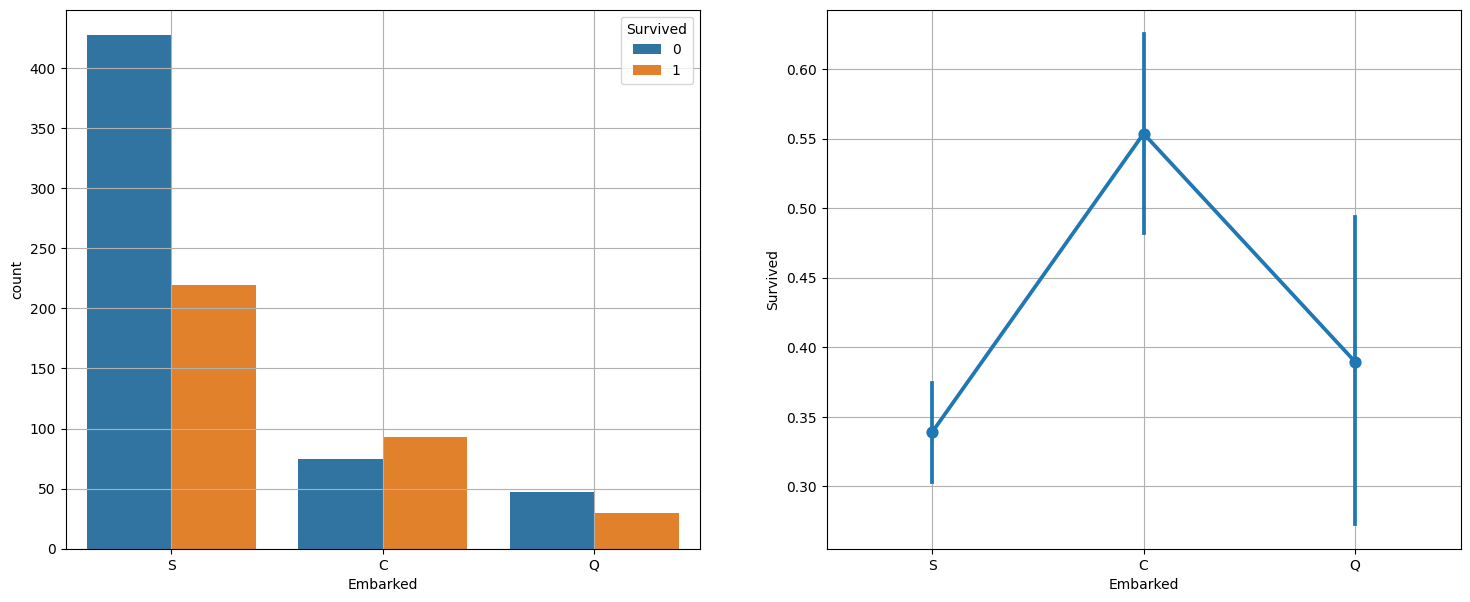

In [27]:
_, axes = plt.subplots (nrows = 1, ncols = 2, figsize = (18, 7))
sns.countplot(
    data = data,
    x = 'Embarked',
    hue = 'Survived',
    ax = axes[0],
)

sns.pointplot(
    data = data,
    x = 'Embarked',
    y = 'Survived',
    ax = axes[1],
)

for ax in axes: ax.grid(True)
plt.show()

# Cabin

Analysis:
* People with a Cabin has up to ~68% of surviving
* This means Cabin maybe something important
* Not many have a cabin, so it must have been purchased

=> Cabin feature may have correlation with Pclass or Fare

In [28]:
for df in all_list:
    df['Cabin_Letter'] = df['Cabin'].apply(
        lambda s: s[0] if pd.notnull(s) else 'Z'
    )
temp = all_df[['Cabin_Letter', 'Pclass', 'PassengerId']].groupby(['Cabin_Letter', 'Pclass']).count().rename(columns={'PassengerId': 'Count'})
temp

Count
Cabin_Letter Pclass       
A            1          22
B            1          65
C            1          94
D            1          40
             2           6
E            1          34
             2           4
             3           3
F            2          13
             3           8
G            3           5
T            1           1
Z            1          67
             2         254
             3         693

Analysis:
* A, B, C, T have only 1st class Passenger
* D, E have quite similar distribution (mostly 1st Class)
* F, G have few passengers

Further inspection is required on distribution of passenger on cabins, and their surviving rate

In [29]:
temp_transpose = temp.transpose()
temp_all = all_df.copy()
cabin_letters = sorted(all_df['Cabin_Letter'].unique().tolist())

letter_counts = {'A': {}, 'B': {}, 'C': {}, 'D': {}, 'E': {}, 'F': {}, 'G': {}, 'T': {}, 'Z': {}}
for letter in cabin_letters:
    for pclass in range(1, 4):
        try:
            count = temp_transpose[(letter, pclass)]['Count']
            letter_counts[letter][pclass] = count
        except KeyError:
            letter_counts[letter][pclass] = 0
df_letter = pd.DataFrame(letter_counts)
letter_percent = {}
for col in df_letter.columns:
    letter_percent[col] = [(count / df_letter[col].sum()) * 100 for count in df_letter[col]]

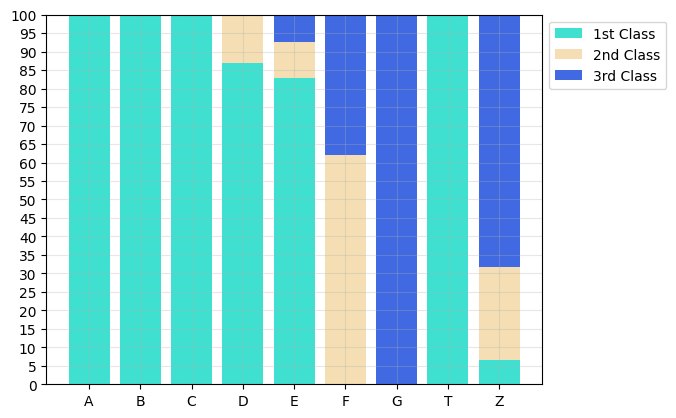

In [30]:
class1 = np.array([letter_percent[letter][0] for letter in cabin_letters])
class2 = np.array([letter_percent[letter][1] for letter in cabin_letters])
class3 = np.array([letter_percent[letter][2] for letter in cabin_letters])
position = np.arange(len(cabin_letters))

plt.bar(position, class1, label='1st Class', color =  'turquoise')
plt.bar(position, class2, bottom=class1, label='2nd Class', color = 'wheat')
plt.bar(position, class3, bottom=class1 + class2, label='3rd Class', color = 'royalblue')

plt.xticks(position, cabin_letters)
plt.yticks(range (0, 105, 5))
plt.legend(loc = 'best', bbox_to_anchor = (1,1))
plt.grid(True, alpha = 0.3)
plt.show()

Analysis:
* As mentioned above, A, B, C, T have similar distribution
* D, E have similar distribution (1st & 2nd class)
* F, G distribution is different; but this is not significant as they have very few passengers

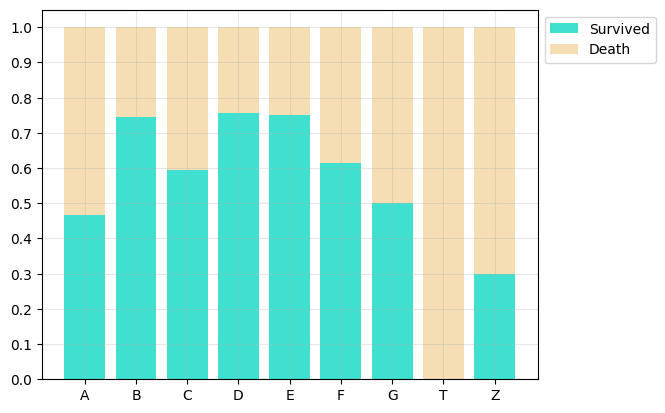

In [31]:
letter_survive = {}
for col in cabin_letters:
    letter_survive[col] = temp_all[temp_all['Cabin_Letter'] == col]['Survived'].mean()

survive_values = np.array([value for value in letter_survive.values()])
plt.bar(position, survive_values, color = 'turquoise', label = 'Survived')
plt.bar(position, 1 - survive_values, bottom = survive_values, color = 'wheat', label = 'Death')
plt.xticks (position, cabin_letters)
plt.yticks (np.arange (0, 1.1, 0.1))
plt.legend (bbox_to_anchor = (1,1))
plt.grid (True, alpha = 0.3)
plt.show()

Analysis: 
* B, D, E all have very high surviving rate
* A, despite having all 1st class, has a 48% surviving rate
* F, G surviving rate is quite similar

Further inspection is required on cabin A

<Axes: xlabel='Sex'>

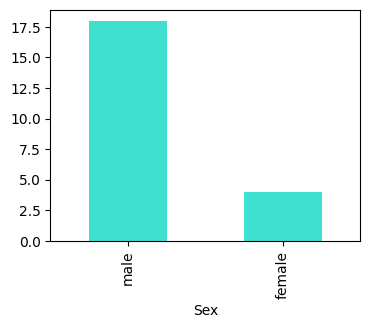

In [32]:
all_df[all_df['Cabin_Letter'] == 'A']['Sex'].value_counts().plot(kind = 'bar', color = 'turquoise', figsize=(4,3))

Analysis:
* The surviving rate in Cabin A was low simple because most passengers on A were Men
* Despite having all men, Cabin A still maintains 48% surviving rate

Conclusion:
* Cabin A is still a good feature; thereby, can still be grouped with B,C,T

In [33]:
for df in all_list:
    df['Cabin_Letter'] = df['Cabin_Letter'].replace (['A', 'B', 'C', 'T'], 'ABCT')
    df['Cabin_Letter'] = df['Cabin_Letter'].replace (['D', 'E'], 'DE')
    df['Cabin_Letter'] = df['Cabin_Letter'].replace (['F', 'G'], 'FG')

for df in all_list:
    if 'Cabin' in df.columns: 
        df.drop ('Cabin', axis = 1, inplace = True)

all_df['Cabin_Letter'].value_counts()

Cabin_Letter
Z       1014
ABCT     182
DE        87
FG        26
Name: count, dtype: int64

In [34]:
submission.isna().any().any() + data.isna().any().any()

np.False_

# Continuous Feature

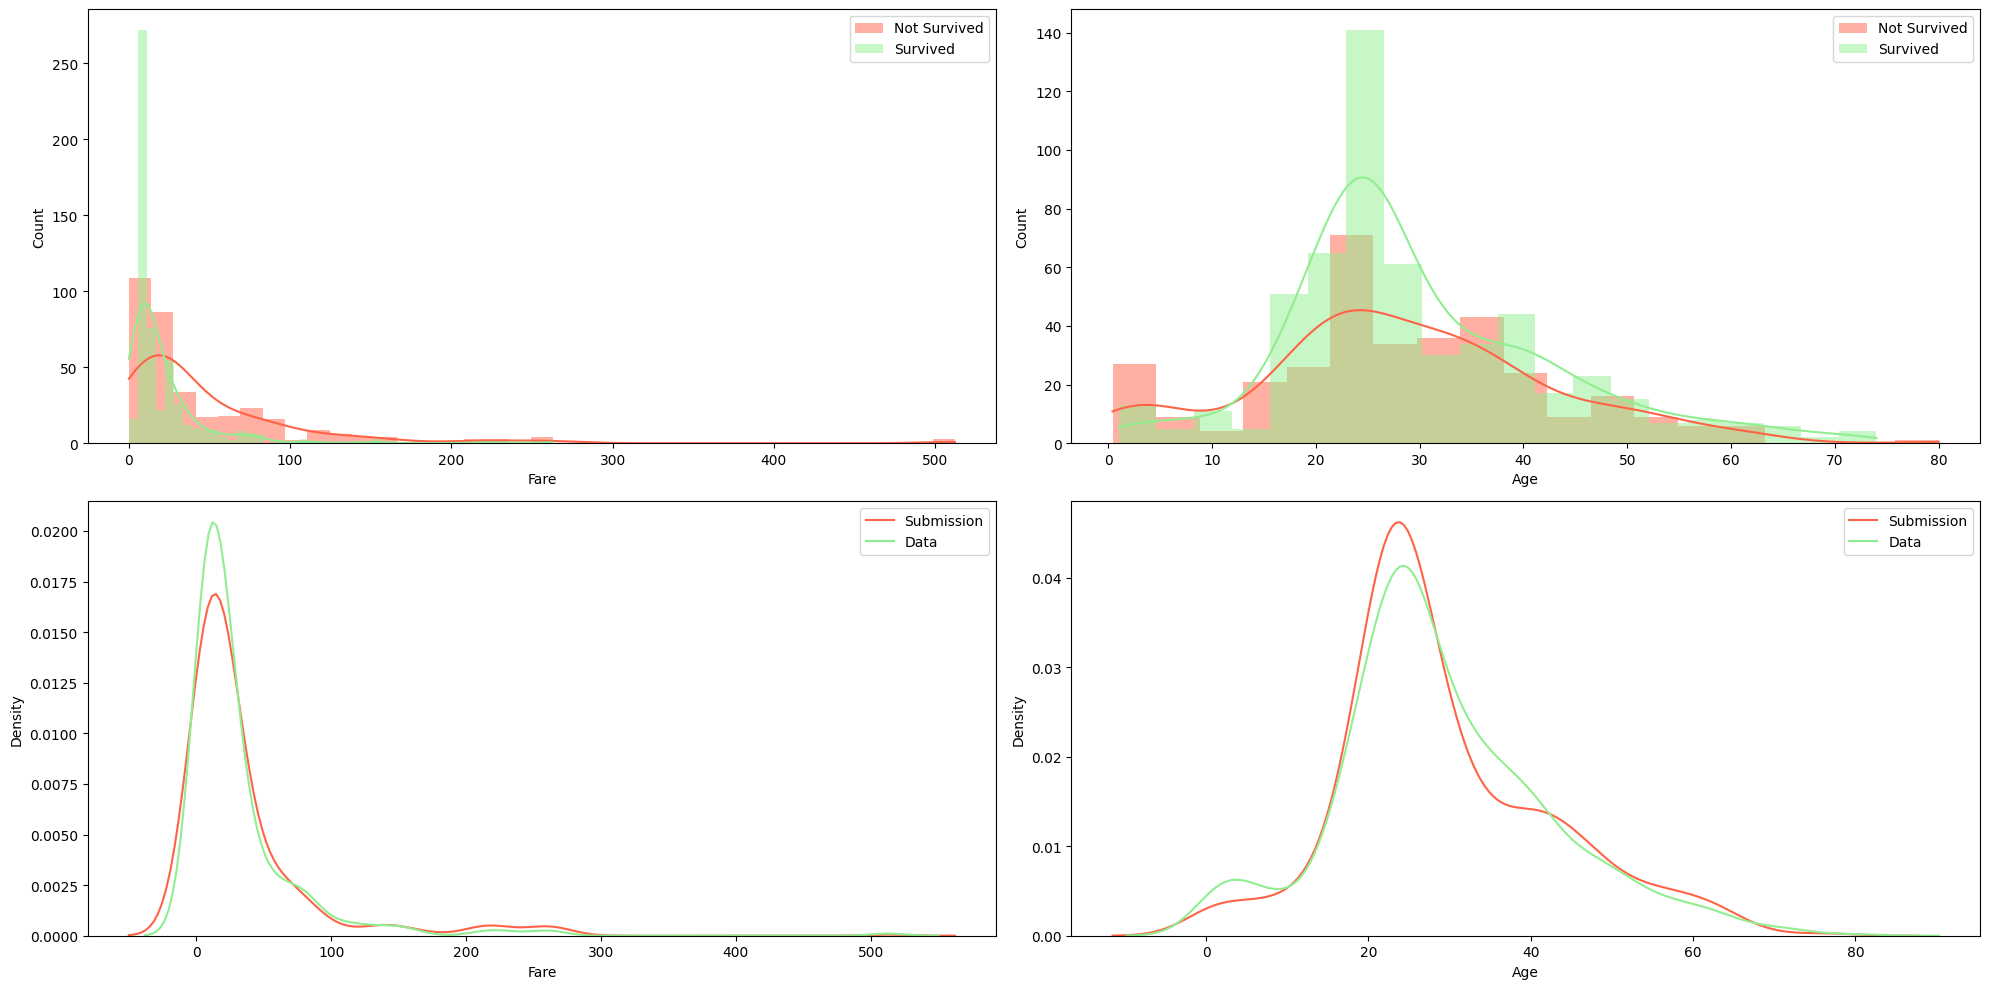

In [35]:
cont_features = ['Fare', 'Age']
death = data['Survived'] == 1
_, axes = plt.subplots (nrows = 2, ncols = 2, figsize = (20, 10))

for i, feature in enumerate(cont_features):
    sns.histplot (
        data[death][feature],
        label = 'Not Survived',
        color = 'tomato',
        ax = axes[0][i],
        edgecolor = None,
        kde = True,
    )
    sns.histplot (
        data = data[~death][feature],
        label = 'Survived',
        ax = axes[0][i],
        color = 'lightgreen',
        edgecolor = None,
        kde = True,
    )
    sns.kdeplot(
        data = submission[feature],
        label = 'Submission',
        ax = axes[1][i],
        color = 'tomato',
    )
    sns.kdeplot (
        data = data[feature],
        label = 'Data',
        ax = axes[1][i],
        color = 'lightgreen',
    )
for ax in axes.flatten():
    xmin, xmax = ax.get_xlim()
    ax.legend()

plt.tight_layout()
plt.show()

Analysis:
* Data distribution of Fare and Age in submission set is smoother than in data set
* Fare has very long tail; meaning that there are many outliers
* The surviving chance of people paid over 300 is not high

Conclusion:
* For models to capture the subtle difference between data set and submission set, continuous features have to be grouped and scaled


# Categorical Features

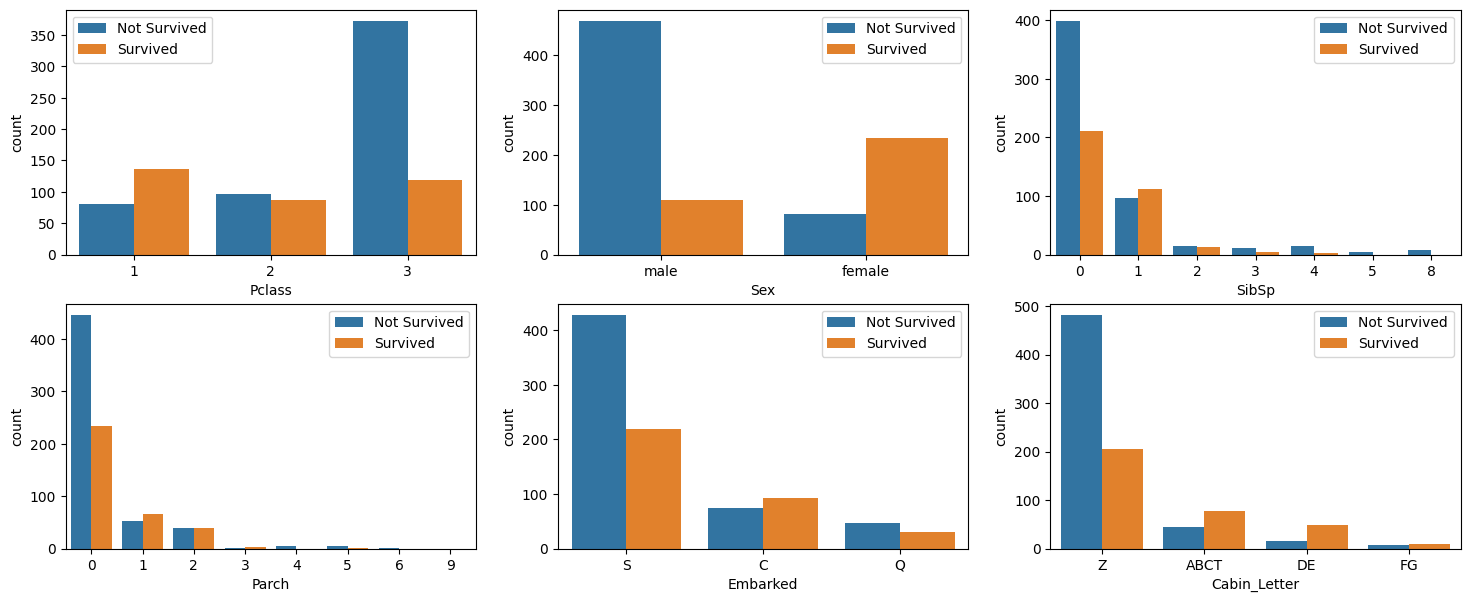

In [36]:
cat_features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Cabin_Letter']
_, axes = plt.subplots (nrows = 2, ncols = 3, figsize = (18, 7))
for i, feature in enumerate(cat_features, 1):
    plt.subplot (2,3,i)
    sns.countplot(
        data = all_df,
        x = feature, 
        hue = 'Survived'
    )
    plt.legend(['Not Survived', 'Survived'])
plt.show()

# Feature Correlation

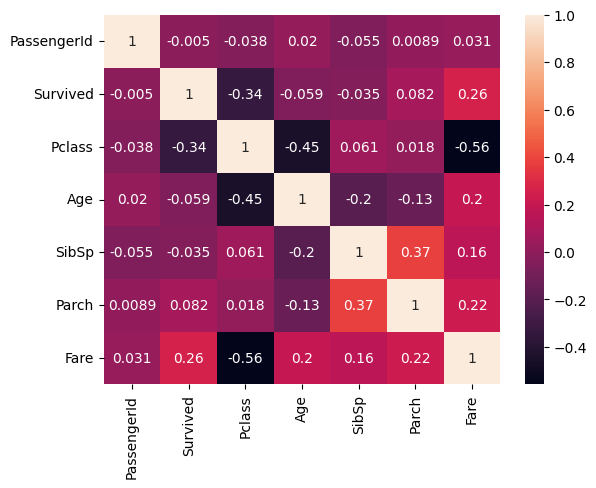

In [37]:
sns.heatmap(all_df.select_dtypes([int, float]).corr(), annot = True)
plt.show()

Analysis:
* The feature are not highly correlated
* Highest Correlation is between Parch and SibSp: 0.37
* Lowest Correlation is between Pclass and Fare: -0.56

Conclusion:
* All features can be kept

# Feature Engineering

As mentioned above, the distribution of Fare and Age is not similar between data and submission sets; therefore, scaling and cutting is required

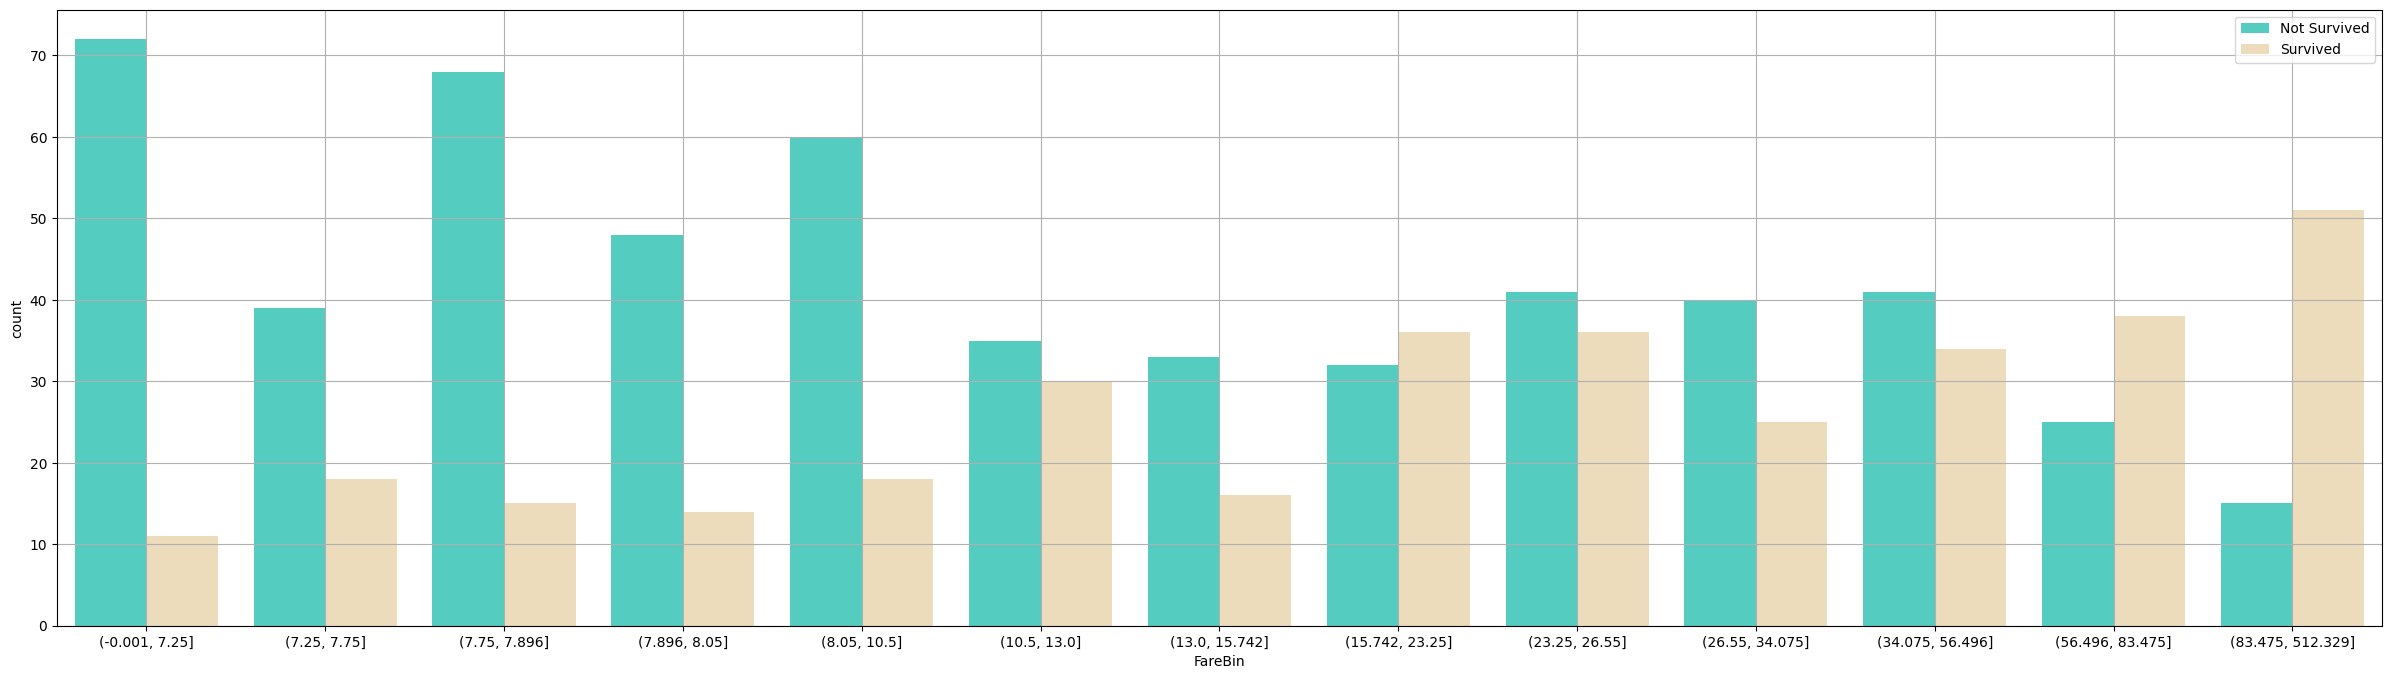

In [38]:
bins = 13
for df in all_list:
    df['FareBin'] = pd.qcut (
        df['Fare'],
        q = bins,
    )

plt.figure (figsize = (30, 8))
sns.countplot(
    data = all_df, 
    x = 'FareBin',
    hue = 'Survived',
    palette=['turquoise', 'wheat']
)

plt.legend (['Not Survived', 'Survived'])
plt.grid (True)
plt.show()

Analysis:
* Only people paid over 55.9 and those paid 15.85 - 24 had higher chance of surviving.
* Death rate is exceptionally high among those who paid less than 10.5

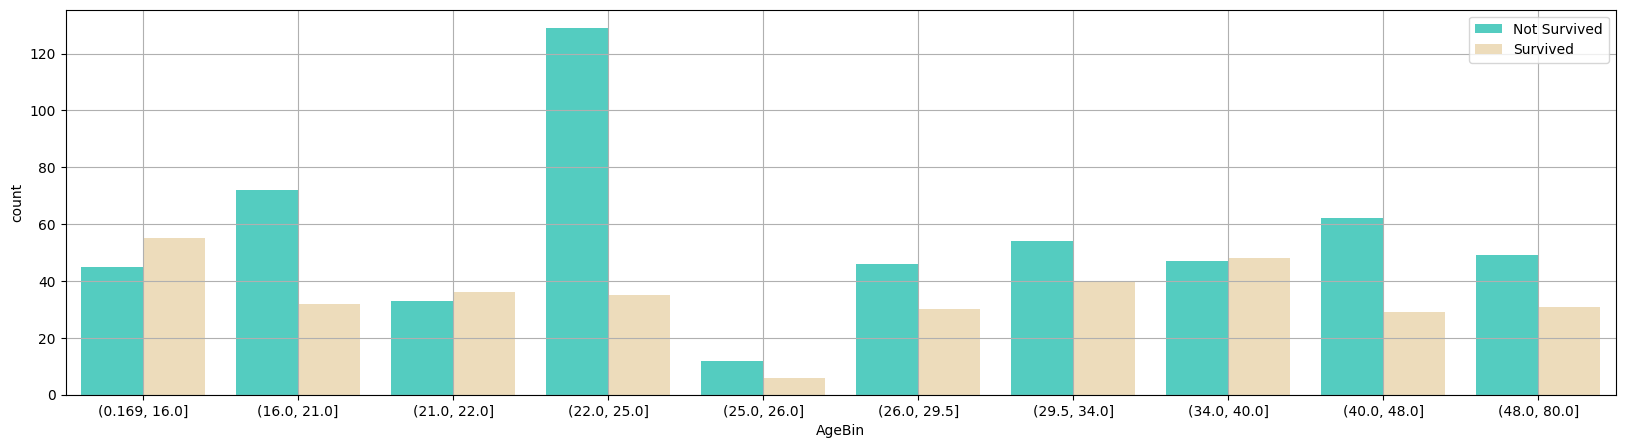

In [39]:
plt.figure (figsize = (20, 5))
bins = 10
for df in all_list:
    df['AgeBin'] = pd.qcut (
        df['Age'], 
        q = bins,
    )

sns.countplot(
    data = all_df,
    x = 'AgeBin',
    hue = 'Survived',
    palette = ['turquoise', 'wheat'],
)

plt.grid (True)
plt.legend (['Not Survived', 'Survived'])
plt.show()

Analysis:
* Young passengers below 17 years old had higher surviving chance
* Those from 21.5 - 25 had highest death rate
* The middle-aged from 30.5 - 36 had higher surviving rate
* Surviving distribution for the remaining was identical, with death rate being higher.

# Accompany
As SibSp and Parch are correlated; it may worth trying to combine these two features

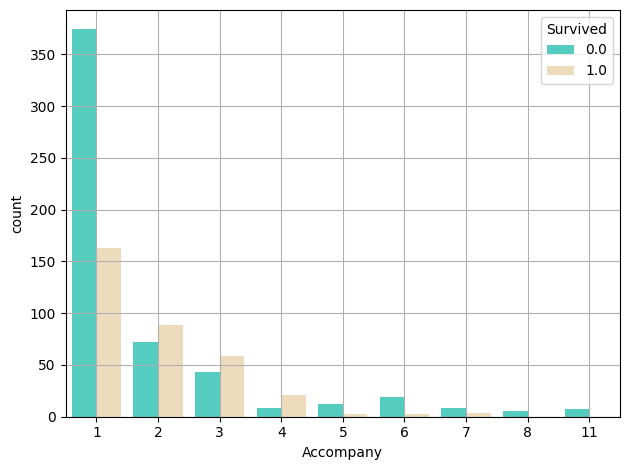

In [40]:
for df in all_list:
    df['Accompany'] = df['SibSp'] + df['Parch'] + 1

sns.countplot(
    data = all_df, 
    x = 'Accompany',
    hue = 'Survived',
    palette=['turquoise', 'wheat'],
)

plt.grid (True)
plt.tight_layout()
plt.show()

Analysis:
* Most passengers travelled alone; this group also had the highest death rate
* Passengers travelled with 1-3 accompany were more likely to survive
* Those who had over 3 companions are not likely to survive

Conclusion:
* It worths grouping 1-3 accompany to one group, and over 4 accompany to one group

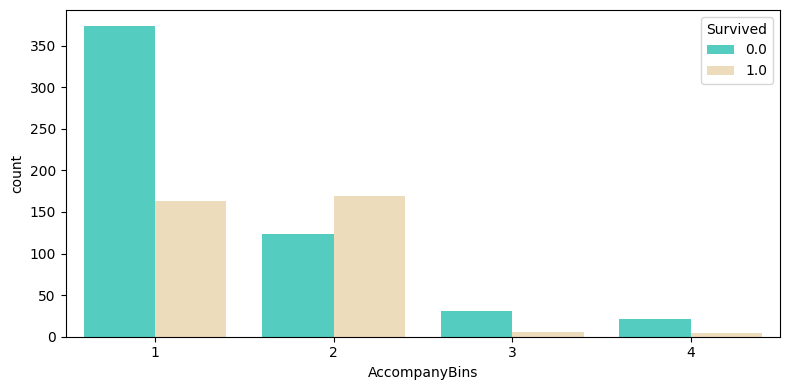

In [41]:
for df in all_list:
    df['AccompanyBins'] = df['Accompany'].apply(
        lambda x: 1 if x == 1 else 2 if x > 1 and x < 5 else 3 if x > 4 and x < 7 else 4
    )

plt.figure (figsize = (8, 4))
sns.countplot(
    data = all_df,
    x = 'AccompanyBins',
    hue = 'Survived',
    palette=['turquoise', 'wheat'],
)

plt.tight_layout()
plt.show()

# Ticket
Let's suppost that If people go with their friends or maid, then their companions will have the same ticket as them. Then, it worths examining the surviving rate of such passengers

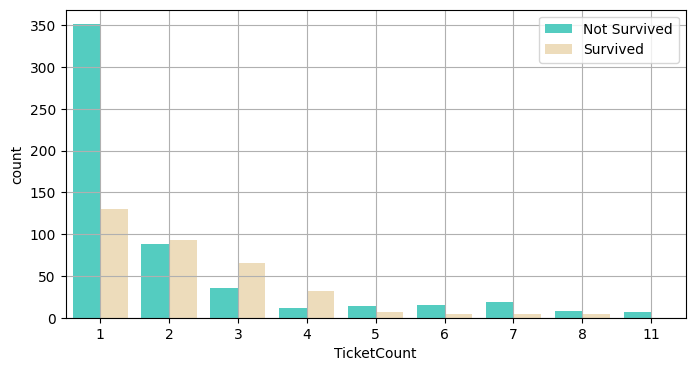

In [42]:
for df in all_list:
    df['TicketCount'] = df.groupby('Ticket')['Ticket'].transform ('count')

plt.figure (figsize = (8, 4))
sns.countplot(
    data = all_df,
    x = 'TicketCount',
    hue = 'Survived',
    palette=['turquoise', 'wheat'],
)

plt.grid (True)
plt.legend (['Not Survived', 'Survived'])
plt.show()

Analysis:
* The pattern was similar with Accompany feature
* Most people go alone
* Passengers departed with 2-3 companions had higher surviving rate
* Those who had over 5 companions were less likely to survive

Conclusion:
* Such pattern makes this feature worth keeping
* It won't be grouped like AccompanyBins because that will make two features highly correlated, hence reducing training efficiency

# Examine Name

In [43]:
all_df['Name'].sample (10)

1167                   Parker, Mr. Clifford Richard
976                              Khalil, Mr. Betros
815                                Fry, Mr. Richard
1130    Douglas, Mrs. Walter Donald (Mahala Dutton)
963                  Nieminen, Miss. Manta Josefina
1151           de Messemaeker, Mr. Guillaume Joseph
1300                      Peacock, Miss. Treasteall
1192                            Malachard, Mr. Noel
883                   Banfield, Mr. Frederick James
413                  Cunningham, Mr. Alfred Fleming
Name: Name, dtype: str

Names are consisted of two components:
* Family name (e.g. West)
* Title (e.g. Mr)

# Title & Married

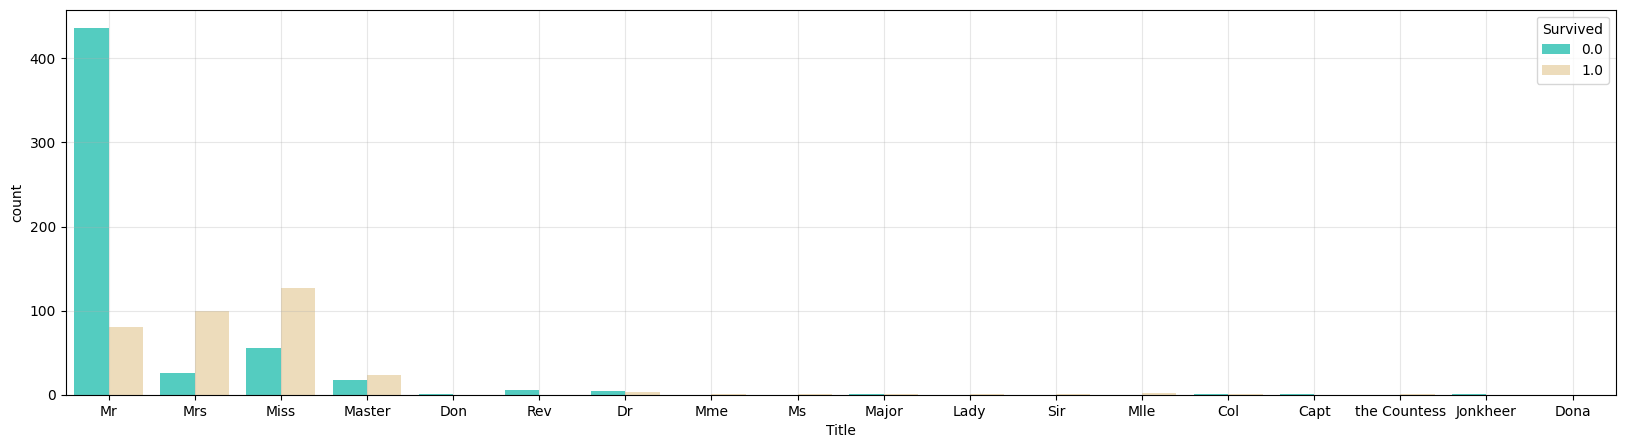

In [44]:
for df in all_list:
    df['Title'] = df['Name'].apply(
        lambda x: x.split (',')[1].split('.')[0].strip()
    )

plt.figure (figsize = (20, 5))
sns.countplot(
    data = all_df, 
    x = 'Title',
    hue = 'Survived',
    palette=['turquoise', 'wheat'],
)

plt.grid (True, alpha = 0.3)
plt.show()

Analysis:
* The profession titles have very few instances
* Miss, and Mrs title have high surviving chance

Conclusion:
* It worths grouping Mrs, Miss and other female title into one group
* A new feature should be created to distinguish Mrs and Miss
* Professions should be grouped to another group

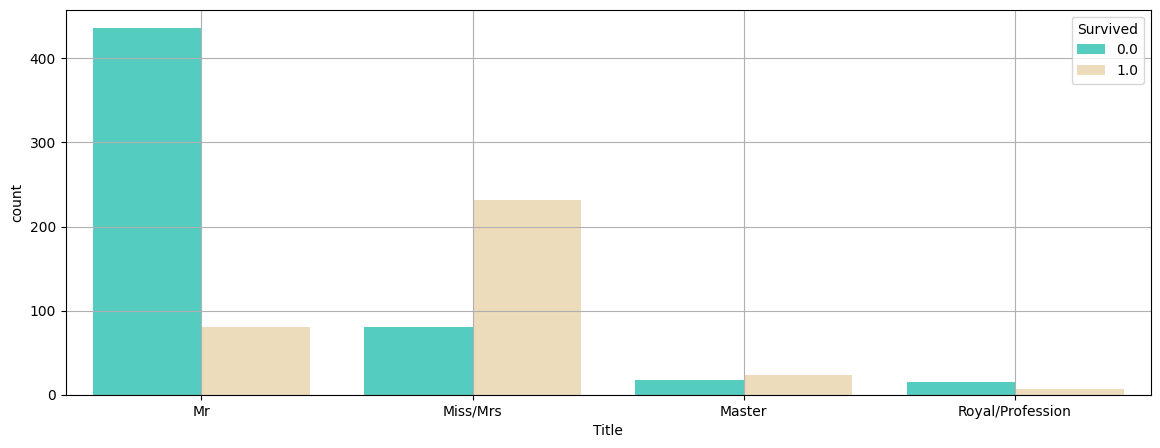

In [45]:
for df in all_list:
    df['Married'] = df['Title'].apply(
        lambda x: 1 if x == "Mrs" else 0
    )
    df['Title'] = df['Title'].replace (['Mrs', 'Miss', 'Ms', 'Mme', 'Ms', 'Lady', 'Mlle', 'Dona'], 'Miss/Mrs')
    df['Title'] = df['Title'].replace (['Don', 'Rev', 'Dr', 'Major', 'Sir', 'Col', 'Capt', 'Jonkheer', 'the Countess'], 'Royal/Profession')

plt.figure (figsize = (14, 5))
sns.countplot(
    data = all_df,
    x = 'Title',
    hue = 'Survived', 
    palette=['turquoise', 'wheat']
)

plt.grid(True)
plt.show()

# Family Name

In [46]:
all_df['Name']

0                                 Braund, Mr. Owen Harris
1       Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                  Heikkinen, Miss. Laina
3            Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                                Allen, Mr. William Henry
                              ...                        
1304                                   Spector, Mr. Woolf
1305                         Oliva y Ocana, Dona. Fermina
1306                         Saether, Mr. Simon Sivertsen
1307                                  Ware, Mr. Frederick
1308                             Peter, Master. Michael J
Name: Name, Length: 1309, dtype: str

In [47]:
import string
for df in all_list:
    df['FamilyName'] = df['Name'].apply(
        lambda x: ''.join(c for c in x.split ('()')[0].split(',')[0] if c not in string.punctuation).strip()
    )
all_df['FamilyName'].unique()

<StringArray>
[         'Braund',         'Cumings',       'Heikkinen',        'Futrelle',
           'Allen',           'Moran',        'McCarthy',         'Palsson',
         'Johnson',          'Nasser',
 ...
         'Colbert', 'LarssonRondberg',          'Conlon',         'Nourney',
         'Riordan',        'Naughton',      'Henriksson',         'Spector',
   'Oliva y Ocana',         'Saether']
Length: 875, dtype: str

# Update data, submission with all_df

In [48]:
data = all_df.loc[:890].copy()
subsmission = all_df.loc[891:].drop ('Survived', axis = 1).copy()
all_list = [data, submission]

data.isna().any().any() + subsmission.isna().any().any()

np.False_

# Survival Rate

In [49]:
data['FamilyName'].head()
data['TicketCount'].head()
data['Accompany']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Accompany, Length: 891, dtype: int64

In [50]:
common_fname = [x for x in data['FamilyName'].unique() if x in submission['FamilyName'].unique()]
common_ticket = [x for x in data['Ticket'].unique() if x in submission['Ticket'].unique()]

family_scount = data.groupby('FamilyName')[['Survived', 'FamilyName','Accompany']].median(numeric_only=True)
ticket_scount = data.groupby('Ticket')[['Survived', 'Ticket','TicketCount']].median(numeric_only=True)

family_srates = {}
ticket_srates = {}

for i in range (len(family_scount)):
    if family_scount.index[i] in common_fname and family_scount.iloc[i, 1] > 1:
        family_srates[family_scount.index[i]] = family_scount.iloc[i, 0]

for i in range (len(ticket_scount)):
    if ticket_scount.index[i] in common_ticket and ticket_scount.iloc[i, 1] > 1:
        ticket_srates[ticket_scount.index[i]] = ticket_scount.iloc[i, 0]

mean_srates = data['Survived'].mean()
name_data_srate = []
name_data_srate_NA = []
name_sub_srate = []
name_sub_srate_NA = []

for i in range (len (data)):
    if data['FamilyName'].iloc[i] in family_srates:
        name_data_srate.append (family_srates[data['FamilyName'][i]])
        name_data_srate_NA.append (1)
    else:
        name_data_srate.append(mean_srates)
        name_data_srate_NA.append (0)

data['Family_Survival_Rate'] = name_data_srate
data['Family_Survival_Rate_NA'] = name_data_srate_NA

for i in range (len (submission)):
    if submission['FamilyName'].iloc[i] in family_srates:
        name_sub_srate.append (family_srates[submission['FamilyName'][i]])
        name_sub_srate_NA.append (1)
    else:
        name_sub_srate.append(mean_srates)
        name_sub_srate_NA.append (0)

submission['Family_Survival_Rate'] = name_sub_srate
submission['Family_Survival_Rate_NA'] = name_sub_srate_NA

ticket_data_srate = []
ticket_data_srate_NA = []
ticket_sub_srate = []
ticket_sub_srate_NA = []

for i in range (len (data)):
    if data['Ticket'].iloc[i] in ticket_srates:
        ticket_data_srate.append (ticket_srates[data['Ticket'][i]])
        ticket_data_srate_NA.append (1)
    else:
        ticket_data_srate.append(mean_srates)
        ticket_data_srate_NA.append (0)

data['Ticket_Survival_Rate'] = ticket_data_srate
data['Ticket_Survival_Rate_NA'] = ticket_data_srate_NA

for i in range (len (submission)):
    if submission['Ticket'].iloc[i] in ticket_srates:
        ticket_sub_srate.append (ticket_srates[submission['Ticket'][i]])
        ticket_sub_srate_NA.append (1)
    else:
        ticket_sub_srate.append(mean_srates)
        ticket_sub_srate_NA.append (0)
submission['Ticket_Survival_Rate'] = ticket_sub_srate
submission['Ticket_Survival_Rate_NA'] = ticket_sub_srate_NA

for df in all_list:
    df['SurviveRate'] = (df['Family_Survival_Rate'] + df['Ticket_Survival_Rate']) / 2
    df['SurviveRate_NA'] = (df['Family_Survival_Rate_NA'] + df['Ticket_Survival_Rate_NA']) / 2

# Feature Transformation

In [51]:
label_features = ['Embarked', 'Sex', 'Cabin_Letter', 'Title', 'AccompanyBins', 'AgeBin', 'FareBin']
label_encoder = LabelEncoder()

for df in all_list:
    for feature in label_features:
        df[feature] = label_encoder.fit_transform (df[feature].astype(str))

In [52]:
one_hot_features = ['Pclass', 'Sex', 'Embarked', 'Cabin_Letter', 'AccompanyBins', 'Title']
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
)

encoder.fit (data[one_hot_features])
def ohe (df: pd.DataFrame, features = one_hot_features):
    encoded_arr = encoder.transform (df[features])
    encoded_df = pd.DataFrame(
        data = encoded_arr, 
        columns = encoder.get_feature_names_out(features),
        index = df.index,
    )
    return encoded_df
data = pd.concat([data, ohe(data)], axis = 1)
submission = pd.concat([submission, ohe(submission)], axis = 1)

In [53]:
drop_features = one_hot_features + ['Name', 'Age', 'Fare', 'SibSp', 'Parch', 'Ticket', 'Accompany', 'FamilyName', 'Family_Survival_Rate', 'Family_Survival_Rate_NA', 'Ticket_Survival_Rate', 'Ticket_Survival_Rate_NA']
def drop(df: pd.DataFrame, features = drop_features):
    for feature in features:
        if feature not in df.columns: continue
        df.drop (feature, axis = 1, inplace = True)

drop(data, drop_features)
drop(submission, drop_features)

In [54]:
all_df = pd.concat ([data, submission], axis = 0).reset_index(drop = True)
x_train = StandardScaler().fit_transform(data.drop(['Survived', 'PassengerId'], axis = 1))
y_train = data['Survived'].values
x_test = StandardScaler().fit_transform(submission.drop('PassengerId', axis = 1).copy())
print (x_train.shape)

print();print (x_test.shape)

(891, 26)

(418, 26)


<Axes: xlabel='feature'>

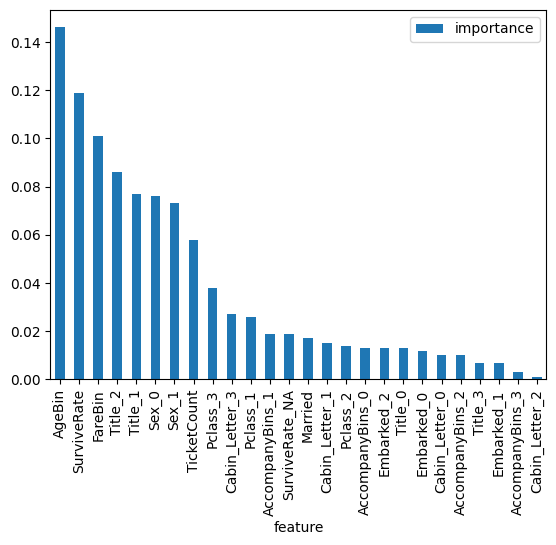

In [55]:
forest_model = RandomForestClassifier(n_estimators=100, oob_score=True)
forest_model.fit(x_train, y_train)

forest_model.score(x_train, y_train)

importances = pd.DataFrame({'feature':data.drop (['PassengerId', 'Survived'], axis = 1).columns,'importance':np.round(forest_model.feature_importances_,3)})

importances = importances.sort_values('importance',ascending=False).set_index('feature')
importances.plot.bar()

# Model Experiment

In [56]:
models = [RandomForestClassifier(n_estimators=300, max_depth = 8, random_state = 42), GradientBoostingClassifier(), HistGradientBoostingClassifier(), KNeighborsClassifier(n_neighbors=5), GaussianNB(), SVC(), XGBClassifier(), LogisticRegression()]

name, acc = [], []
trainx, testx, trainy, testy = train_test_split(
    StandardScaler().fit_transform(data.drop(columns=['Survived', 'PassengerId'])), 
    data['Survived'],
    test_size = 0.2,
    stratify = data['Survived'],
    random_state = 42,
)

for model in models:
    model.fit (trainx, trainy)
    name.append (type(model).__name__)
    y_pred = model.predict (testx)
    acc.append(accuracy_score(testy, y_pred))
    

perf = pd.DataFrame({
    'name': name, 
    'accuracy': acc,
})

perf.sort_values('accuracy', ascending=False)

,name,accuracy
0,RandomForestClassifier,0.837989
7,LogisticRegression,0.826816
2,HistGradientBoostingClassifier,0.821229
5,SVC,0.815642
6,XGBClassifier,0.810056
1,GradientBoostingClassifier,0.804469
3,KNeighborsClassifier,0.776536
4,GaussianNB,0.770950


In [57]:
def fine_tune(objective, model_class, trials = 100):
    name = type(model_class()).__name__ + '.pkl'
    if os.path.exists (name):
        model = joblib.load (name)
        return model

    study = optuna.create_study(
        directions = ['maximize', 'maximize'],
        sampler=optuna.samplers.NSGAIIISampler(),
        pruner=optuna.pruners.MedianPruner(
            n_min_trials=7,
            n_startup_trials=2,
            interval_steps=3,
        )
    )
    study.optimize(
        objective, 
        n_trials=trials,
    )

    pareto = study.best_trials
    df = pd.DataFrame({
        'acc': [t.values[0] for t in pareto],
        'gap': [t.values[1] for t in pareto],
        'trial': [t.number for t in pareto],
    })

    df['gap'] = df['gap'].apply(lambda x: min (x, 0))
    df['perfect_rate'] = np.sqrt (
        (1 - df['acc']) ** 2
        + 
        (df['gap']) ** 2
    )
    best_idx = df['perfect_rate'].idxmin()
    params = pareto[best_idx].params
    model = model_class(**params)
    model.fit (x_train, y_train)
    joblib.dump (model, name)
    return model

In [ ]:
def forest_objective (trial):
    # n_estimators = trial.suggest_categorical ('n_estimators', [100, 300, 500, 1000, 1700, 2000])
    # max_depth = trial.suggest_categorical('max_depth', [3,5,7,9])
    # min_samples_split = trial.suggest_categorical ('min_samples_split', [2,4,6,8,10])
    # min_samples_leaf = trial.suggest_categorical ('min_samples_leaf', [2,4,6,8,10])
    # criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    # max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    n_estimators = trial.suggest_categorical ('n_estimators', [2000])
    max_depth = trial.suggest_categorical('max_depth', [7])
    min_samples_split = trial.suggest_categorical ('min_samples_split', [2])
    min_samples_leaf = trial.suggest_categorical ('min_samples_leaf', [8])
    max_features = trial.suggest_categorical('max_features', ['sqrt'])
    criterion = trial.suggest_categorical('criterion', ['gini'])
    random_state = trial.suggest_categorical ('random_state', [42])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state = random_state,
    )
    
    scores = cross_val_score(
        model, 
        x_train, y_train, 
        scoring = 'accuracy',
        cv = 10,
        n_jobs = -1,
    )
    val_score = scores.mean() - scores.std()

    model.fit (trainx, trainy)
    y_pred = model.predict(testx)
    test_score = accuracy_score(testy, y_pred)
    gap = test_score - val_score

    return val_score, gap 
    
forest_model = fine_tune(forest_objective, RandomForestClassifier)

[I 2026-04-23 22:32:41,676] A new study created in memory with name: no-name-a7ef9a34-21b7-4bcf-ad7c-24fb575e7dd2
[I 2026-04-23 22:32:52,624] Trial 0 finished with values: [0.797676305119479, 0.045899113874934505] and parameters: {'n_estimators': 2000, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini', 'random_state': 42}.


In [59]:
y_pred = forest_model.predict (x_test).astype(int)
result = pd.DataFrame({
        "PassengerId": submission["PassengerId"],
        "Survived": y_pred
    })
result.to_csv ('forest_tuned.csv', index = False)

In [60]:
def lr_objective(trial):
    # solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])
    # if solver == 'lbfgs':
    #     penalty = 'l2'
    # else:
    #     penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    # C = trial.suggest_float('C', 1e-5, 100, log=True)
    # max_iter = trial.suggest_int('max_iter', 100, 1000)

    solver = trial.suggest_categorical('solver', ['lbfgs'])
    penalty = trial.suggest_categorical('penalty', ['l2'])
    C = trial.suggest_categorical('C', [0.0342961072140629])
    max_iter = trial.suggest_categorical('max_iter', [327])
    tol=trial.suggest_float('tol', 1e-7, 1.0, log = True)

    model = LogisticRegression(
        solver=solver,
        penalty=penalty,
        C=C,
        max_iter=max_iter,
        tol=tol,
    )

    scores = cross_val_score(
        model, 
        x_train, y_train, 
        cv=10, 
        scoring='accuracy'
    )
    val_score = scores.mean() - scores.std()

    model.fit (trainx, trainy)
    y_pred = model.predict (testx)
    test_score = accuracy_score(testy, y_pred)
    
    gap = test_score - val_score

    return val_score, gap

lr_model = fine_tune(lr_objective, LogisticRegression, trials = 60)
lr_model

[I 2026-04-23 22:32:54,849] A new study created in memory with name: no-name-2f86352a-a263-4f04-9332-8352e64e090e
[I 2026-04-23 22:32:54,880] Trial 0 finished with values: [0.8158144874081161, 0.016587747228755334] and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.0342961072140629, 'max_iter': 327, 'tol': 0.005959573574295707}.
[I 2026-04-23 22:32:54,897] Trial 1 finished with values: [0.7750681439925857, -0.015291607679736585] and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.0342961072140629, 'max_iter': 327, 'tol': 0.15307600829083803}.
[I 2026-04-23 22:32:54,931] Trial 2 finished with values: [0.8145854529822651, 0.023403373833377317] and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.0342961072140629, 'max_iter': 327, 'tol': 0.0001230362751596558}.
[I 2026-04-23 22:32:54,987] Trial 3 finished with values: [0.8145854529822651, 0.023403373833377317] and parameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.0342961072140629, 'max_iter': 327, 'tol': 2.46

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.0342961072140629
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.005959573574295707
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of prob

In [61]:
y_pred = lr_model.predict (x_test).astype(int)
result = pd.DataFrame({
        "PassengerId": submission["PassengerId"],
        "Survived": y_pred
    })
result.to_csv ('lr_tuned.csv', index = False)

In [62]:
def hgb_objective (trial):
    # learning_rate=trial.suggest_float ('learning_rate', 0.01, 0.2, log = True)
    # max_iter=trial.suggest_int ('max_iter', 100, 1000)
    # max_leaf_nodes=trial.suggest_categorical ('max_leaf_nodes', [5, 8, 12, 20, 30, 50, 70, 100, 200])
    # max_depth=trial.suggest_int ('max_depth', 3, 15)
    # min_samples_leaf=trial.suggest_categorical ('min_samples_leaf', [3, 10, 20, 40, 50, 80, 100, 200])
    # l2_regularization=trial.suggest_float('l2_regularization', 1e-8, 1.0, log = True)

    min_samples_leaf = trial.suggest_int ('min_samples_leaf', 10, 20)
    max_depth=trial.suggest_categorical ('max_depth', [4,5,6])
    max_leaf_nodes = trial.suggest_categorical ('max_leaf_nodes', [10,11,12])
    learning_rate = trial.suggest_categorical ('learning_rate', [0.017240892195821537])
    max_iter = trial.suggest_categorical ('max_iter', [500, 537, 550])
    l2_regularization = trial.suggest_float('l2_regularization', 1e-8, 1.0, log = True)

    model = HistGradientBoostingClassifier(
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
    )
    
    scores = cross_val_score(
        model, 
        x_train, y_train, 
        scoring = 'accuracy',
        cv = 10,
        n_jobs = -1,
    )

    val_score = scores.mean() - scores.std()
    model.fit (trainx, trainy)
    test_score = accuracy_score(testy, model.predict (testx))

    gap = test_score - val_score
    return val_score, gap
    
hgb_model = fine_tune(hgb_objective, HistGradientBoostingClassifier, trials = 40)

[I 2026-04-23 22:32:57,086] A new study created in memory with name: no-name-197e980c-2733-4f51-86a8-275f25b93a37
[I 2026-04-23 22:33:00,802] Trial 0 finished with values: [0.8183492867267501, -0.013880012983733314] and parameters: {'min_samples_leaf': 17, 'max_depth': 6, 'max_leaf_nodes': 11, 'learning_rate': 0.017240892195821537, 'max_iter': 537, 'l2_regularization': 0.0011277501086683225}.
[I 2026-04-23 22:33:01,752] Trial 1 finished with values: [0.8171089905870229, 0.004120059692306666] and parameters: {'min_samples_leaf': 15, 'max_depth': 4, 'max_leaf_nodes': 10, 'learning_rate': 0.017240892195821537, 'max_iter': 550, 'l2_regularization': 0.0006868195057453553}.
[I 2026-04-23 22:33:02,857] Trial 2 finished with values: [0.8179268786505537, -0.007871012728766003] and parameters: {'min_samples_leaf': 14, 'max_depth': 6, 'max_leaf_nodes': 11, 'learning_rate': 0.017240892195821537, 'max_iter': 500, 'l2_regularization': 0.0014181868065744024}.
[I 2026-04-23 22:33:03,957] Trial 3 finis

In [63]:
y_pred = hgb_model.predict (x_test).astype(int)
result = pd.DataFrame({
        "PassengerId": submission["PassengerId"],
        "Survived": y_pred
    })
result.to_csv ('hgb_tuned.csv', index = False)

In [64]:
def svc_objective (trial):
    # kernel = trial.suggest_categorical ('kernel', ['rbf', 'linear'])
    # C = trial.suggest_float ('C', 1e-8, 1.0, log = True)
    # tol = trial.suggest_float ('tol', 1e-5, 1e-2, log = True)

    kernel = trial.suggest_categorical ('kernel', ['linear'])
    C = trial.suggest_categorical ('C', [0.03143475016605715])
    tol = trial.suggest_categorical ('tol', [2.7014209495684817e-05])
    probability = trial.suggest_categorical ('probability', [True])
    max_iter = trial.suggest_int ('max_iter', 100, 1000)

    model = SVC(
        kernel=kernel,
        C=C,
        tol=tol,
        probability=probability,
        max_iter=max_iter,
    )

    scores = cross_val_score(
        model,
        x_train, y_train,
        cv = 10,
        scoring = 'accuracy',
        n_jobs = -1,
    )
    val_score = scores.mean() - scores.std()

    model.fit (trainx, trainy)
    y_pred = model.predict (testx)
    test_score = accuracy_score(testy, y_pred)
    gap = test_score - val_score

    return val_score, gap

svc_model = fine_tune (svc_objective, SVC, trials = 100)
svc_model

[I 2026-04-23 22:33:35,877] A new study created in memory with name: no-name-ff3f66b1-ef72-4410-bb1b-561e9f281c5f
[I 2026-04-23 22:33:35,998] Trial 0 finished with values: [0.8121266838512952, 0.020275550785576302] and parameters: {'kernel': 'linear', 'C': 0.03143475016605715, 'tol': 2.7014209495684817e-05, 'probability': True, 'max_iter': 757}.
[I 2026-04-23 22:33:36,098] Trial 1 finished with values: [0.8121266838512952, 0.020275550785576302] and parameters: {'kernel': 'linear', 'C': 0.03143475016605715, 'tol': 2.7014209495684817e-05, 'probability': True, 'max_iter': 554}.
[I 2026-04-23 22:33:36,199] Trial 2 finished with values: [0.8121266838512952, 0.020275550785576302] and parameters: {'kernel': 'linear', 'C': 0.03143475016605715, 'tol': 2.7014209495684817e-05, 'probability': True, 'max_iter': 734}.
[I 2026-04-23 22:33:36,300] Trial 3 finished with values: [0.8121266838512952, 0.0258621429643473] and parameters: {'kernel': 'linear', 'C': 0.03143475016605715, 'tol': 2.7014209495684

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.03143475016605715
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",2.7014209495684817e-05
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [65]:
y_pred = svc_model.predict (x_test).astype(int)
result = pd.DataFrame({
        "PassengerId": submission["PassengerId"],
        "Survived": y_pred
    })

result.to_csv ('svc_tuned.csv', index = False)

In [ ]:
vote_model = VotingClassifier(
    estimators=[
        ('svc', svc_model),
        ('lr', lr_model),
        ('hgb', hgb_model),
    ],

    voting = 'soft',
)
vote_model.fit (x_train, y_train)
y_pred = vote_model.predict (x_test).astype(int)
result = pd.DataFrame({
    'PassengerId': submission['PassengerId'],
    'Survived': y_pred,
})
result.to_csv ('vote_model.csv', index = False)